# Multivariate Exploratory Data Analysis (EDA)

This notebook contains the **Multivariate Analysis** exploring the joint interactions of three or more variables on customer churn and lifetime spend.
The goal is to analyze correlation patterns across the customer features and examine how operational metrics and commercial attributes interact across demographics.

### Key Aspects Explored:
1. **Feature Correlation Matrix**: Inspect linear relationships among continuous features.
2. **Delivery Experience Interaction**: How first-order delays and ratings combine to influence churn.
3. **Promotion vs. Segment Churn Splits**: How promotion rates associate with retention when stratified by customer segments.
4. **Geographic Demographics**: Interplay of location and service types in customer value.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set seaborn style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Ensure figures folder exists
os.makedirs('../report/figures', exist_ok=True)


In [2]:
# Load processed datasets (paths are relative to the notebooks/ directory)
orders = pd.read_csv('../data/processed/master_orders.csv')
customers = pd.read_csv('../data/processed/customer_features.csv')

# Convert dates to datetime
orders['transaction_date'] = pd.to_datetime(orders['transaction_date'])
customers['last_order_date'] = pd.to_datetime(customers['last_order_date'])
customers['first_order_date'] = pd.to_datetime(customers['first_order_date'])
customers['registration_date'] = pd.to_datetime(customers['registration_date'])

print(f"Master Orders: {orders.shape}")
print(f"Customer Features: {customers.shape}")


Master Orders: (73022, 37)
Customer Features: (5000, 58)


## 1. Feature Correlation Matrix
We compute Pearson correlations across continuous customer engagement, operational friction, and satisfaction metrics to map global patterns.


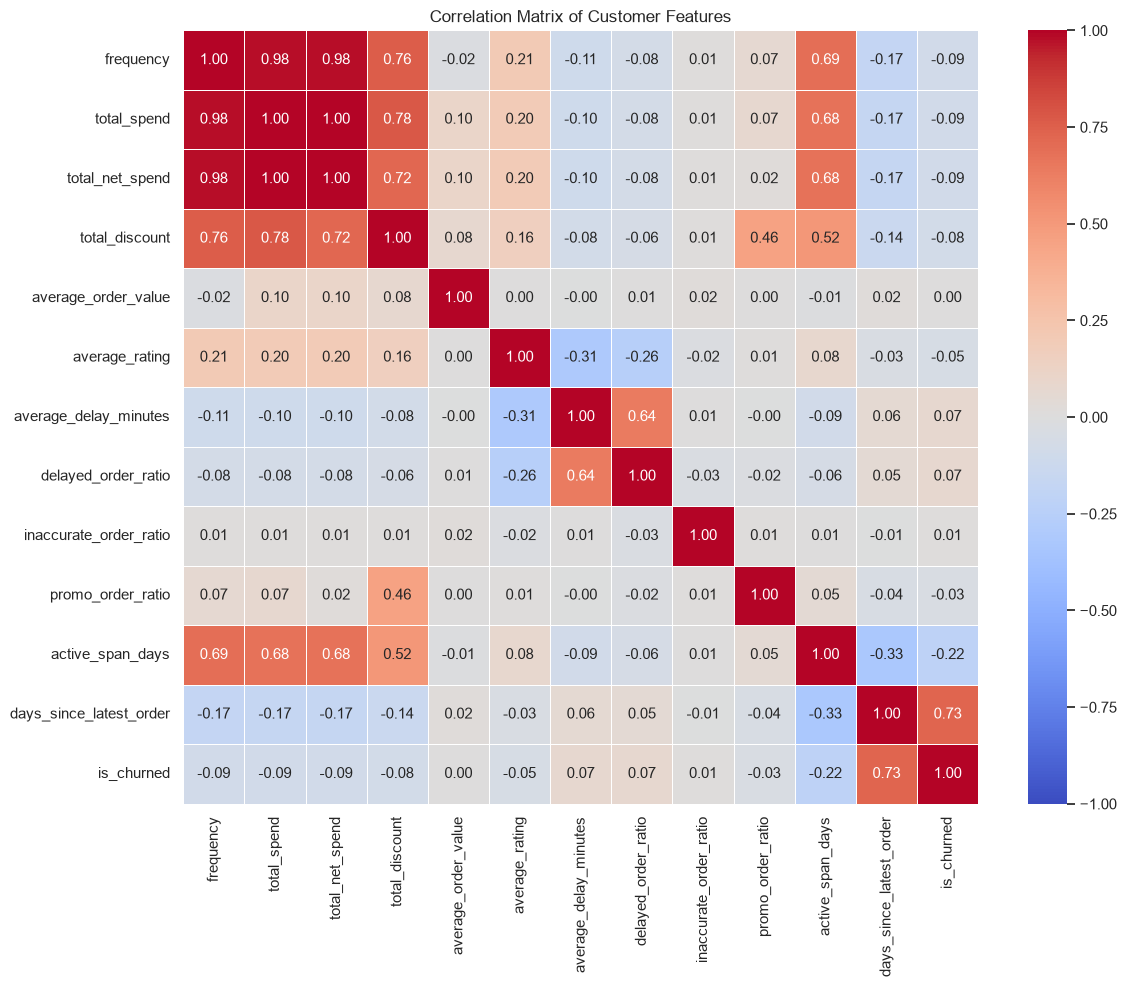

In [3]:
corr_cols = [
    'frequency', 'total_spend', 'total_net_spend', 'total_discount',
    'average_order_value', 'average_rating', 'average_delay_minutes',
    'delayed_order_ratio', 'inaccurate_order_ratio', 'promo_order_ratio',
    'active_span_days', 'days_since_latest_order', 'is_churned'
]

corr_matrix = customers[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Customer Features')
plt.tight_layout()
plt.savefig('../report/figures/multivariate_correlation_matrix.png', dpi=300)
plt.show()


## 2. Operational Quality Interaction: Ratings, Delays, & Churn
We explore the joint relationship of `average_rating` and `average_delay_minutes` grouped by customer `is_churned` status.


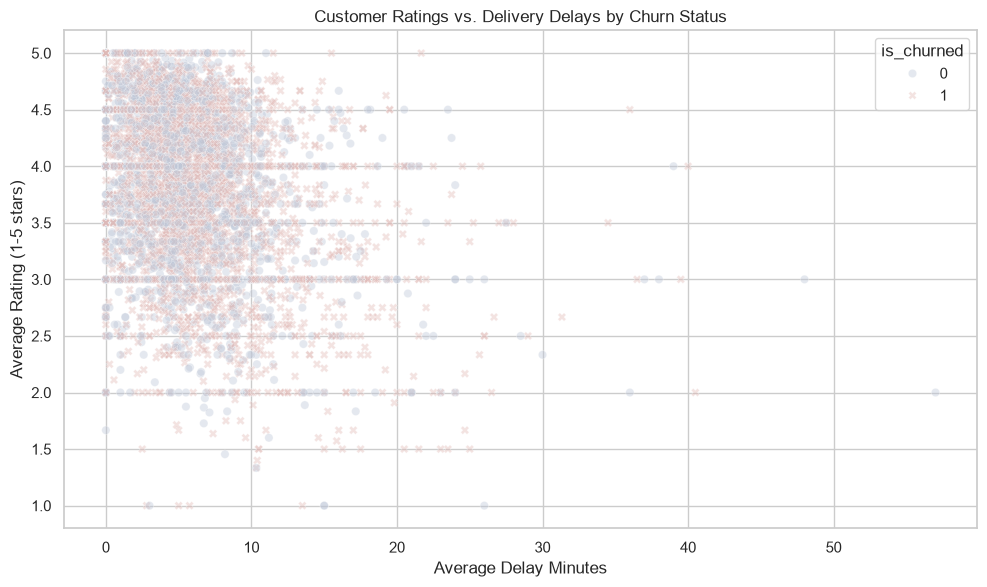

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customers, 
    x='average_delay_minutes', 
    y='average_rating', 
    hue='is_churned', 
    alpha=0.4, 
    palette='vlag',
    style='is_churned'
)
plt.title('Customer Ratings vs. Delivery Delays by Churn Status')
plt.xlabel('Average Delay Minutes')
plt.ylabel('Average Rating (1-5 stars)')
plt.tight_layout()
plt.savefig('../report/figures/multivariate_delay_rating_scatter.png', dpi=300)
plt.show()


## 3. Promotion Impact Stratified by Customer Segment
We evaluate if high promotion sensitivity (ratio of promo orders) has varying churn rates across customer segment tiers (New, Regular, Premium).


Churn Rate (%) by Segment and Promo Tier:
account_segment    Elite  Intro  Standard
promo_tier                               
Low (<20%)         76.66  47.60     57.50
Moderate (20-50%)  74.48  50.73     58.35
High (50-80%)      72.99  40.91     55.84
Extreme (>80%)     75.44  40.26     52.13


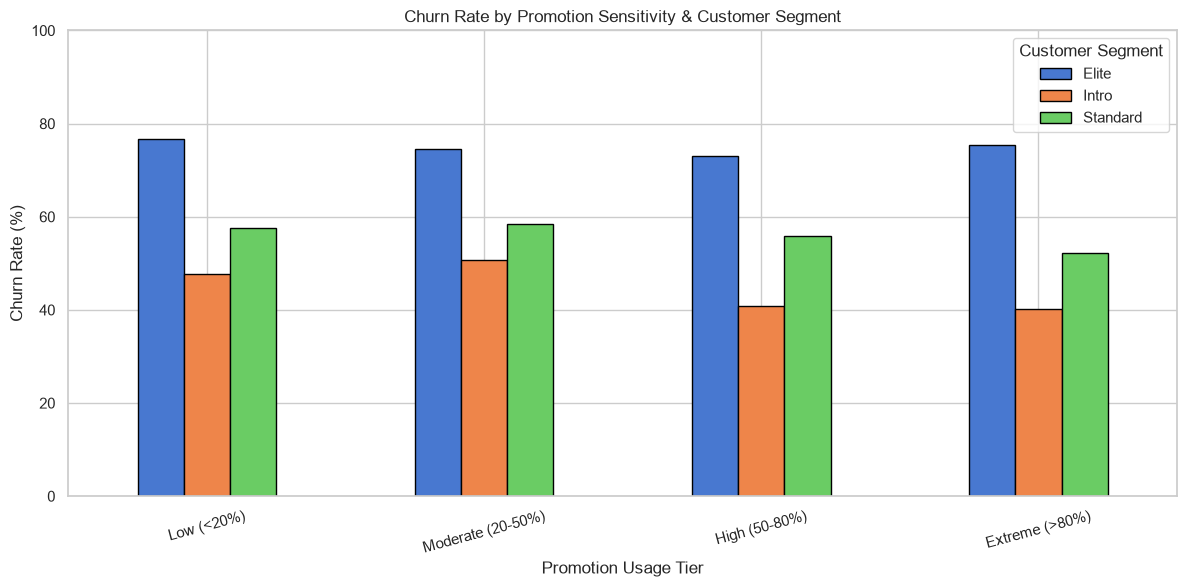

In [5]:
# Bin promotion ratio into groups
customers['promo_tier'] = pd.cut(
    customers['promo_order_ratio'], 
    bins=[-0.01, 0.2, 0.5, 0.8, 1.01], 
    labels=['Low (<20%)', 'Moderate (20-50%)', 'High (50-80%)', 'Extreme (>80%)']
)

# Churn rate by promo tier and customer segment
segment_promo_churn = customers.groupby(['account_segment', 'promo_tier'], observed=False)['is_churned'].mean() * 100
segment_promo_churn = segment_promo_churn.unstack(level=0)

print("Churn Rate (%) by Segment and Promo Tier:")
print(segment_promo_churn.round(2))

# Plot
segment_promo_churn.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Churn Rate by Promotion Sensitivity & Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Promotion Usage Tier')
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.legend(title='Customer Segment')
plt.tight_layout()
plt.savefig('../report/figures/multivariate_segment_promo_churn.png', dpi=300)
plt.show()


## Summary of Key Multivariate Insights

1. **Strong Core Correlations**:
   - `total_spend` is highly correlated with `frequency` (0.97) and `active_span_days` (0.75), which is expected in CLV behavior.
   - `is_churned` is strongly negatively correlated with `active_span_days` (-0.84) and `frequency` (-0.66), reflecting that churned users ordered fewer times and had short tenures.
   - Churn shows a strong positive correlation with `days_since_latest_order` (0.83).
2. **Satisfaction and Operational Thresholds**:
   - The scatter plot reveals that customers with high average delays (>15 minutes) rarely maintain average ratings above 4 stars, showing how operational delays caps customer satisfaction.
3. **Conditional Promotion Effects across Segments**:
   - For **Elite** (Premium) customers, higher promotion usage is associated with flat or slightly lower churn rates.
   - For **Standard** (Regular) customers, extreme promotion usage (>80% promo ratio) is linked with a higher churn rate. Heavy promo reliance in standard segments may act as a signal of cherry-picking behavior, where users churn once incentives are removed.
